This notebook is used to understand the PaySim financial transaction dataset before cleaning, preprocessing, feature engineering, and model training.

The dataset is large, so it will not be opened in Excel. Instead, we will inspect it safely using Python and Pandas.

Main goals of this notebook:

- Verify dataset path
- Check sample rows
- Check total rows and columns
- Understand column names
- Check data types
- Check missing values
- Check fraud and non-fraud transaction count
- Understand transaction type distribution

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/raw/paysim_transactions.csv"

In [9]:
df_sample = pd.read_csv(file_path, nrows=10)
df_sample

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


We are reading only 10 rows first because the dataset is very large. This helps us quickly confirm that the file is loading correctly.

In [10]:
df_sample.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [11]:
total_rows = sum(1 for _ in open(file_path, encoding="utf-8")) - 1
total_columns = len(df_sample.columns)

print("Total Rows:", total_rows)
print("Total Columns:", total_columns)
print("Dataset Shape:", (total_rows, total_columns))

Total Rows: 6362620
Total Columns: 11
Dataset Shape: (6362620, 11)


In [13]:
# Load bigger sample data for more understanding
df_preview = pd.read_csv(file_path, nrows=100000)
df_preview.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [14]:
df_preview.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
99995,10,PAYMENT,4020.66,C1410794718,159929.0,155908.34,M1257036576,0.00,0.00,0,0
99996,10,PAYMENT,18345.49,C744303677,6206.0,0.00,M1785344556,0.00,0.00,0,0
99997,10,CASH_IN,183774.91,C104331851,39173.0,222947.91,C36392889,54925.05,0.00,0,0
99998,10,CASH_OUT,82237.17,C707662966,6031.0,0.00,C1553004158,592635.66,799140.46,0,0
99999,10,PAYMENT,20096.56,C1868032458,110117.0,90020.44,M1419201886,0.00,0.00,0,0


In [15]:
df_preview.sample(10, random_state=42)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
75721,10,CASH_IN,367088.24,C291409265,1328.10,368416.34,C1132709076,2312937.66,3837053.94,0,0
80184,10,PAYMENT,27004.49,C535489359,0.00,0.00,M2110652315,0.00,0.00,0,0
19864,8,PAYMENT,2173.75,C927615422,820.00,0.00,M1658216730,0.00,0.00,0,0
76699,10,TRANSFER,19670.92,C1562020231,5416.73,0.00,C2060926688,63327.50,0.00,0,0
92991,10,PAYMENT,17394.26,C1165434512,168543.14,151148.88,M490546299,0.00,0.00,0,0
76434,10,PAYMENT,5590.22,C1215244108,21731.00,16140.78,M51179144,0.00,0.00,0,0
84004,10,PAYMENT,21406.06,C1931483834,184.00,0.00,M860915641,0.00,0.00,0,0
80917,10,CASH_IN,130398.29,C106093299,24404.00,154802.29,C1792016053,0.00,0.00,0,0
60767,9,PAYMENT,3471.26,C840422888,0.00,0.00,M881608445,0.00,0.00,0,0
50074,9,CASH_OUT,282516.89,C242902390,1376786.46,1094269.57,C1186819207,1048155.47,1651625.76,0,0


In [16]:
df_preview.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [17]:
df_preview.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [18]:
# Transaction type distribution
df_preview["type"].value_counts()

type
PAYMENT     39512
CASH_OUT    30718
CASH_IN     20185
TRANSFER     8597
DEBIT         988
Name: count, dtype: int64

In [19]:
# Fraud count in preview
df_preview["isFraud"].value_counts()

isFraud
0    99884
1      116
Name: count, dtype: int64

In [20]:
fraud_rate = df_preview["isFraud"].mean() * 100
print("Fraud Rate in Preview Data:", round(fraud_rate, 4), "%")

Fraud Rate in Preview Data: 0.116 %


***Fraud detection datasets are usually imbalanced, meaning fraud transactions are very small compared to normal transactions.***

In [21]:
# Full fraud count using chunks
fraud_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(file_path, usecols=["isFraud"], chunksize=500000):
    fraud_counts = fraud_counts.add(chunk["isFraud"].value_counts(), fill_value=0)

fraud_counts = fraud_counts.astype(int)
fraud_counts

isFraud
0    6354407
1       8213
dtype: int64

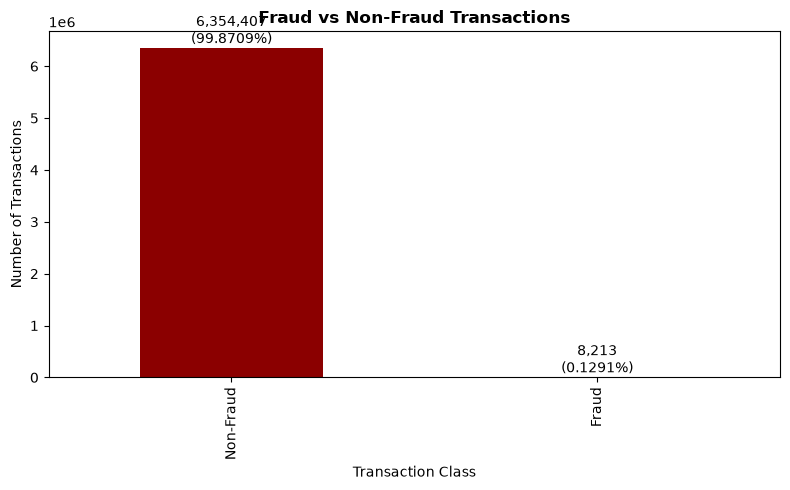

In [40]:
fraud_counts.index = ["Non-Fraud", "Fraud"]

plt.figure(figsize=(8, 5))
ax = fraud_counts.plot(kind="bar", color=["#8B0000", "#DC143C"])

plt.title("Fraud vs Non-Fraud Transactions", fontweight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for i, v in enumerate(fraud_counts.values):
    plt.text(i, v, f"{v:,}\n({v / fraud_counts.sum() * 100:.4f}%)", ha="center", va="bottom")

plt.tight_layout()
plt.show()

This calculates fraud and non-fraud count from the full dataset without loading the whole file at once.

In [22]:
# Full transaction type count using chunks
type_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(file_path, usecols=["type"], chunksize=500000):
    type_counts = type_counts.add(chunk["type"].value_counts(), fill_value=0)

type_counts = type_counts.astype(int)
type_counts

type
CASH_IN     1399284
CASH_OUT    2237500
DEBIT         41432
PAYMENT     2151495
TRANSFER     532909
dtype: int64

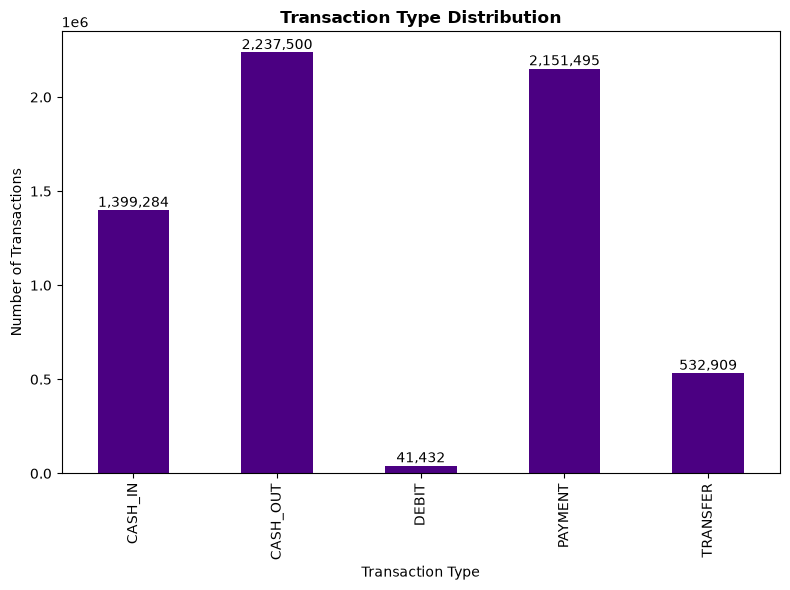

In [42]:
plt.figure(figsize=(8,6))
ax = type_counts.plot(kind="bar", color="#4B0082")

plt.title("Transaction Type Distribution", fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for i, v in enumerate(type_counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [43]:
# flagged fraud count
flagged_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(file_path, usecols=["isFlaggedFraud"], chunksize=500000):
    flagged_counts = flagged_counts.add(chunk["isFlaggedFraud"].value_counts(), fill_value=0)

flagged_counts = flagged_counts.astype(int)
flagged_counts

isFlaggedFraud
0    6362604
1         16
dtype: int64

In [23]:
# Basic amount statistics
df_preview["amount"].describe()

count    1.000000e+05
mean     1.736022e+05
std      3.443003e+05
min      3.200000e-01
25%      9.963562e+03
50%      5.274552e+04
75%      2.117631e+05
max      1.000000e+07
Name: amount, dtype: float64

In [24]:
df_preview[["isFraud", "isFlaggedFraud"]].value_counts()

isFraud  isFlaggedFraud
0        0                 99884
1        0                   116
Name: count, dtype: int64

## Notebook Summary

In this notebook, we performed the initial understanding of the PaySim financial transaction dataset using Python instead of Excel because the dataset is too large to open safely in spreadsheet tools.

### Key Findings

- The dataset contains **6,362,620 rows** and **11 columns**.
- The target variable for fraud detection is **`isFraud`**.
- `isFraud = 0` means a normal transaction, and `isFraud = 1` means a fraudulent transaction.
- The dataset has **6,354,407 non-fraud transactions** and **8,213 fraud transactions**.
- The fraud rate is approximately **0.1291%**, which shows that this is a highly imbalanced dataset.
- There are no missing values in the preview sample.
- The main transaction types are **CASH_OUT, PAYMENT, CASH_IN, TRANSFER, and DEBIT**.
- The most frequent transaction types are **CASH_OUT** and **PAYMENT**.
- The `amount` column has a wide range, so scaling or transformation may be needed during model preparation.
- The `isFlaggedFraud` column shows whether the original system flagged a transaction as suspicious.
- In the full dataset, only **16 transactions** are flagged as fraud by this column, while **6,362,604 transactions** are not flagged.
- This is very small compared to the actual **8,213 fraud transactions** in `isFraud`.
- This means `isFlaggedFraud` is not enough to detect fraud properly, because it misses most fraudulent transactions.
- Therefore, `isFraud` will be used as the actual target variable, and `isFlaggedFraud` will be analyzed carefully before deciding whether to use it as a feature.

### Important Understanding

This is not a normal balanced classification problem. Since fraud cases are very rare, accuracy alone will not be enough to judge the model. In later stages, more focus should be given to **recall, precision, F1-score, confusion matrix, and false negatives**.

The columns `nameOrig` and `nameDest` are account identifiers, so they should not be used directly as normal model features. The `type` column is categorical and will need encoding during feature engineering.

### Next Step

The next step will be detailed EDA and data cleaning. I will analyze fraud patterns by transaction type, compare fraud and non-fraud transaction amounts, check balance changes, and prepare the dataset for feature engineering and model training.